# Dataset Analysis — `instances_attributes_val2020_clean.json`

Análise exploratória do dataset final, cobrindo:
1. **Tamanho geral** — anotações, imagens, categorias, atributos
2. **Insights de categorias** — frequência e ranking
3. **Insights de atributos** — frequência e ranking
4. **Insights por imagem** — distribuição de categorias e atributos únicos por imagem

In [14]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from collections import Counter, defaultdict

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

DATA_PATH = 'final_datasets\\instances_attributes_val2020_clean_no_selected_categories.json'

with open(DATA_PATH, 'r', encoding='utf-8') as f:
    data = json.load(f)

annotations = data['annotations']
categories  = {c['id']: c['name'] for c in data['categories']}
attributes  = {a['id']: a['name'] for a in data['attributes']}

print(f'JSON carregado: {DATA_PATH}')

JSON carregado: final_datasets\instances_attributes_val2020_clean_no_selected_categories.json


## 1. Tamanho Geral do Dataset

In [15]:
unique_images      = set(a['image_id'] for a in annotations)
n_annotations      = len(annotations)
n_images           = len(unique_images)
n_categories_vocab = len(categories)
n_attributes_vocab = len(attributes)

# Categorias e atributos realmente presentes nas anotações
cats_used  = set(a['category_id'] for a in annotations)
attrs_used = set(aid for a in annotations for aid in a['attribute_ids'])

summary = pd.DataFrame({
    'Métrica': [
        'Total de anotações',
        'Imagens únicas',
        'Categorias no vocabulário',
        'Categorias usadas nas anotações',
        'Atributos no vocabulário',
        'Atributos usados nas anotações',
    ],
    'Valor': [
        n_annotations,
        n_images,
        n_categories_vocab,
        len(cats_used),
        n_attributes_vocab,
        len(attrs_used),
    ]
})

display(summary.set_index('Métrica'))

,Valor
Métrica,
Total de anotações,194285
Imagens únicas,45622
Categorias no vocabulário,39
Categorias usadas nas anotações,39
Atributos no vocabulário,294
Atributos usados nas anotações,254


## 2. Insights de Categorias

In [16]:
# Contagem de anotações por categoria
cat_counter = Counter(a['category_id'] for a in annotations)

cat_df = pd.DataFrame([
    {'category_id': cid, 'name': categories.get(cid, f'id={cid}'), 'count': cnt}
    for cid, cnt in cat_counter.most_common()
])
cat_df['rank'] = range(1, len(cat_df) + 1)
cat_df['pct']  = (cat_df['count'] / n_annotations * 100).round(2)

print(f'Top 15 categorias mais frequentes (total: {len(cat_df)})')
display(cat_df[['rank','name','count','pct']].head(15).rename(
    columns={'rank': 'Rank', 'name': 'Categoria', 'count': 'Anotações', 'pct': '%'}
).set_index('Rank'))

Top 15 categorias mais frequentes (total: 39)


,Categoria,Anotações,%
Rank,,,
1,shoe,46374,23.87
2,dress,18739,9.65
3,"top, t-shirt, sweatshirt",16548,8.52
4,pants,12414,6.39
5,zipper,7991,4.11
6,jacket,7833,4.03
7,"bag, wallet",7217,3.71
8,belt,6851,3.53
9,"shirt, blouse",6161,3.17


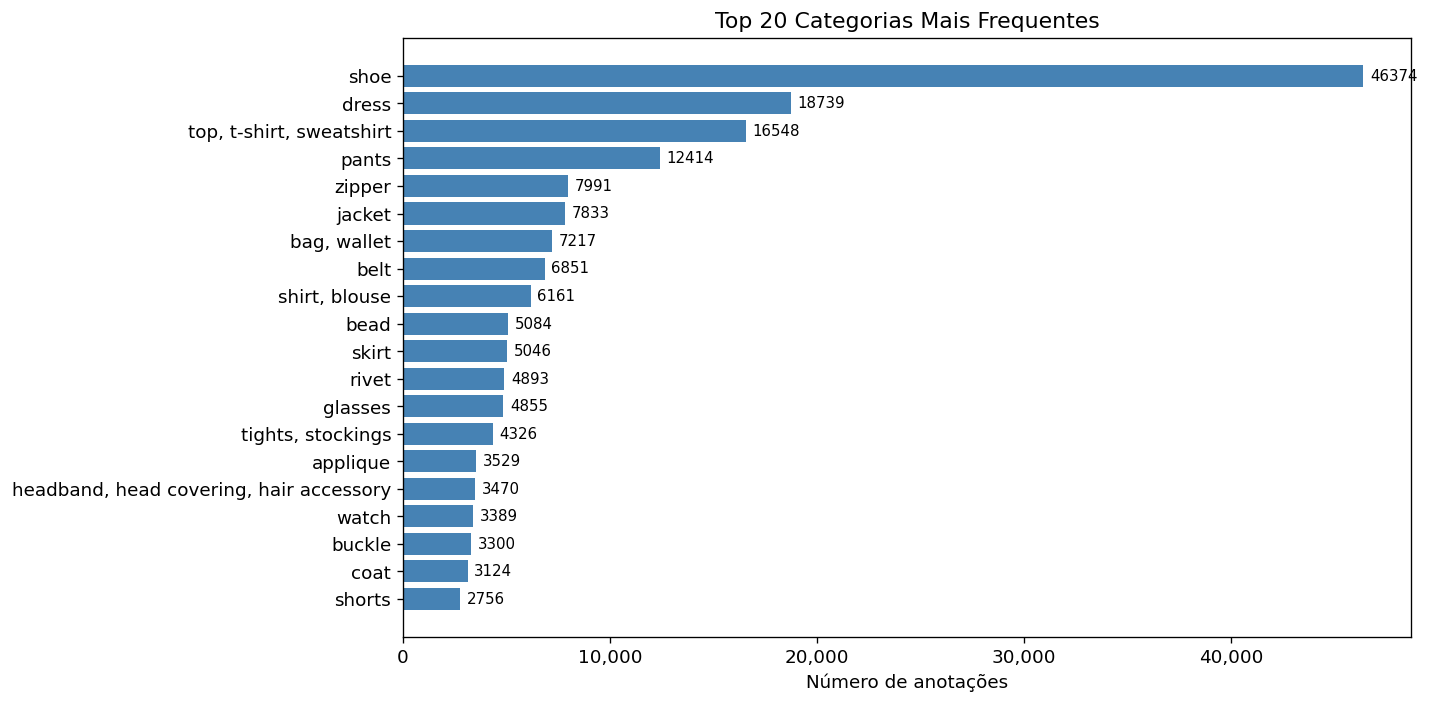

In [17]:
# Gráfico — Top 20 categorias
top_n = 20
top_cats = cat_df.head(top_n)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_cats['name'][::-1], top_cats['count'][::-1], color='steelblue')
ax.bar_label(bars, labels=top_cats['count'][::-1].astype(str), padding=4, fontsize=9)
ax.set_xlabel('Número de anotações')
ax.set_title(f'Top {top_n} Categorias Mais Frequentes')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## 3. Insights de Atributos

In [18]:
# Contagem de ocorrências por atributo (cada anotação pode ter vários)
attr_counter = Counter(
    aid for a in annotations for aid in a['attribute_ids']
)

total_attr_occurrences = sum(attr_counter.values())
print(f'Total de ocorrências de atributos: {total_attr_occurrences:,}')
print(f'Anotações sem nenhum atributo: {sum(1 for a in annotations if not a["attribute_ids"]):,}')
print()

attr_df = pd.DataFrame([
    {'attribute_id': aid, 'name': attributes.get(aid, f'id={aid}'), 'count': cnt}
    for aid, cnt in attr_counter.most_common()
])
attr_df['rank'] = range(1, len(attr_df) + 1)
attr_df['pct']  = (attr_df['count'] / total_attr_occurrences * 100).round(2)

print('Top 15 atributos mais frequentes')
display(attr_df[['rank','name','count','pct']].head(15).rename(
    columns={'rank': 'Rank', 'name': 'Atributo', 'count': 'Ocorrências', 'pct': '%'}
).set_index('Rank'))

Total de ocorrências de atributos: 581,015
Anotações sem nenhum atributo: 117,316

Top 15 atributos mais frequentes


,Atributo,Ocorrências,%
Rank,,,
1,no non-textile material,65847,11.33
2,symmetrical,60154,10.35
3,plain (pattern),58458,10.06
4,no special manufacturing technique,38341,6.60
5,normal waist,25019,4.31
6,regular (fit),24666,4.25
7,no waistline,18941,3.26
8,above-the-hip (length),17440,3.00
9,zip-up,16859,2.90


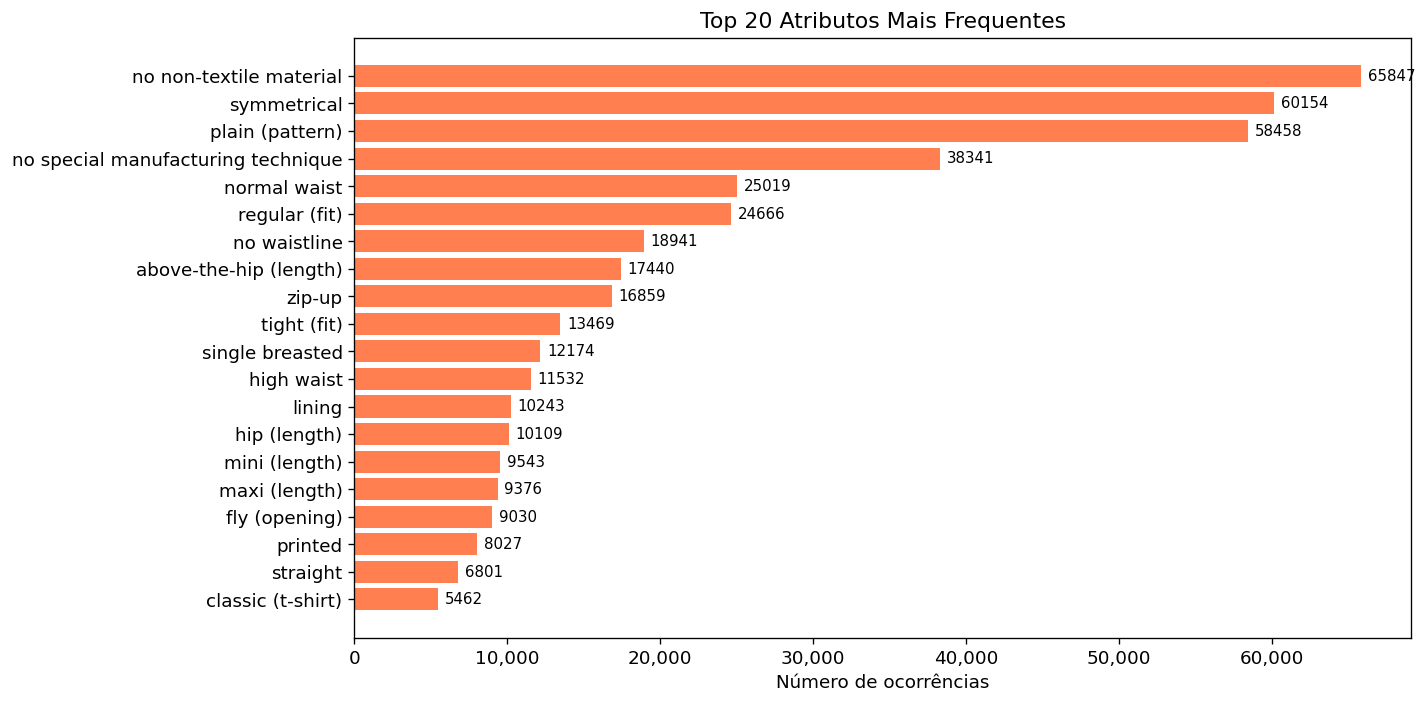

In [19]:
# Gráfico — Top 20 atributos
top_n = 20
top_attrs = attr_df.head(top_n)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_attrs['name'][::-1], top_attrs['count'][::-1], color='coral')
ax.bar_label(bars, labels=top_attrs['count'][::-1].astype(str), padding=4, fontsize=9)
ax.set_xlabel('Número de ocorrências')
ax.set_title(f'Top {top_n} Atributos Mais Frequentes')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## 4. Insights por Imagem

In [20]:
# Agrupa anotações por imagem
img_cats   = defaultdict(set)
img_attrs  = defaultdict(set)
img_ann_n  = defaultdict(int)

for a in annotations:
    iid = a['image_id']
    img_cats[iid].add(a['category_id'])
    img_attrs[iid].update(a['attribute_ids'])
    img_ann_n[iid] += 1

per_image = pd.DataFrame({
    'image_id'       : list(unique_images),
    'n_annotations'  : [img_ann_n[i]       for i in unique_images],
    'n_categories'   : [len(img_cats[i])   for i in unique_images],
    'n_attributes'   : [len(img_attrs[i])  for i in unique_images],
})

print('Estatísticas por imagem')
display(per_image[['n_annotations','n_categories','n_attributes']].describe().round(2))

Estatísticas por imagem


,n_annotations,n_categories,n_attributes
count,45622.00,45622.00,45622.00
mean,4.26,3.32,10.51
std,2.75,1.75,3.06
min,1.00,1.00,0.00
25%,2.00,2.00,8.00
50%,4.00,3.00,10.00
75%,6.00,4.00,13.00
max,69.00,13.00,24.00


In [21]:
# Médias resumidas
means = per_image[['n_annotations','n_categories','n_attributes']].mean()
print(f'Média de anotações por imagem  : {means["n_annotations"]:.2f}')
print(f'Média de categorias únicas/img : {means["n_categories"]:.2f}')
print(f'Média de atributos únicos/img  : {means["n_attributes"]:.2f}')

Média de anotações por imagem  : 4.26
Média de categorias únicas/img : 3.32
Média de atributos únicos/img  : 10.51


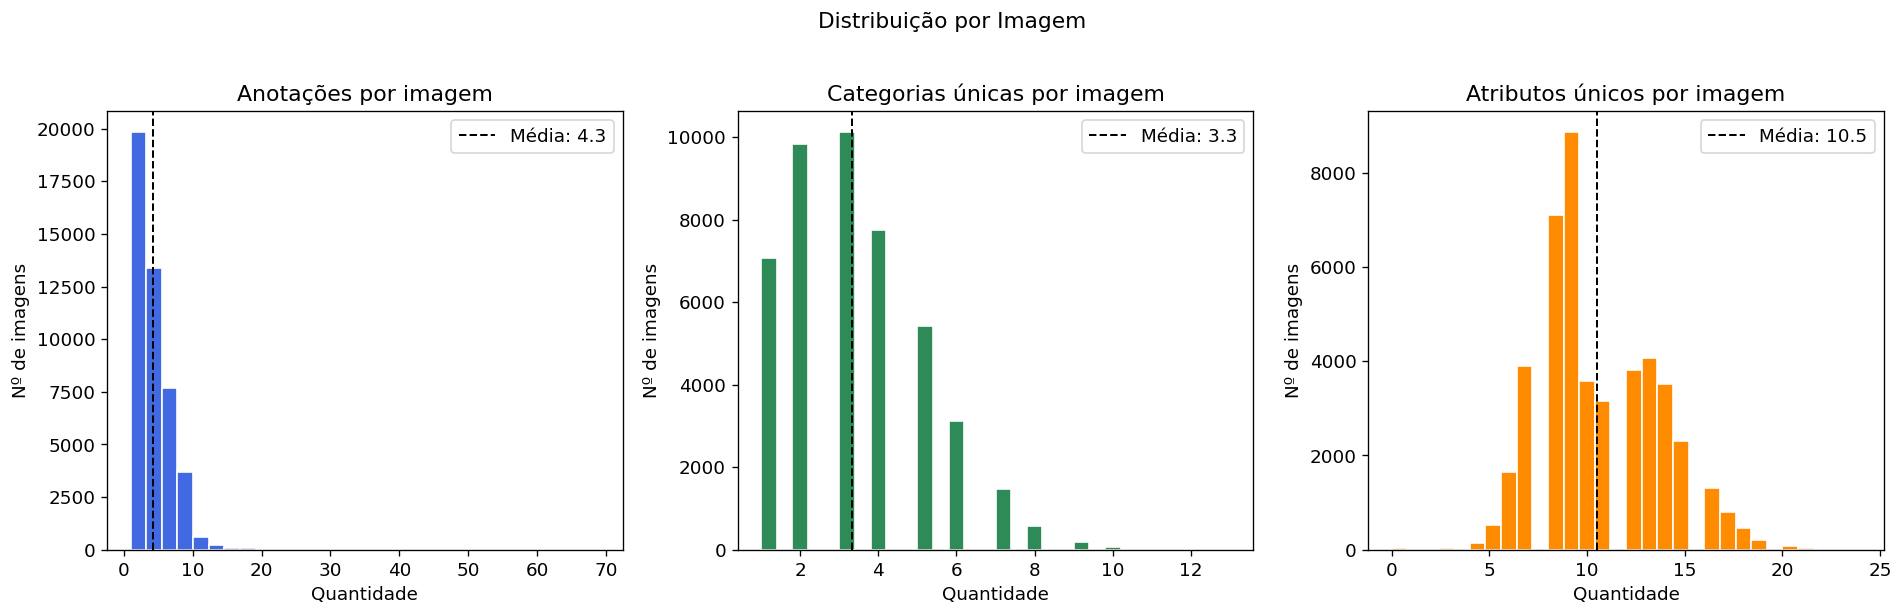

In [22]:
# Histogramas de distribuição
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

cols_labels = [
    ('n_annotations', 'Anotações por imagem',      'royalblue'),
    ('n_categories',  'Categorias únicas por imagem', 'seagreen'),
    ('n_attributes',  'Atributos únicos por imagem',  'darkorange'),
]

for ax, (col, title, color) in zip(axes, cols_labels):
    ax.hist(per_image[col], bins=30, color=color, edgecolor='white')
    ax.axvline(per_image[col].mean(), color='black', linestyle='--', linewidth=1.2,
               label=f'Média: {per_image[col].mean():.1f}')
    ax.set_title(title)
    ax.set_xlabel('Quantidade')
    ax.set_ylabel('Nº de imagens')
    ax.legend()

plt.suptitle('Distribuição por Imagem', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [23]:




# Ranking de imagens — mais ricas em categorias e atributos
top_by_cats  = per_image.nlargest(10, 'n_categories')[['image_id','n_categories','n_attributes','n_annotations']]
top_by_attrs = per_image.nlargest(10, 'n_attributes')[['image_id','n_attributes','n_categories','n_annotations']]

print('Top 10 imagens com mais categorias únicas')
display(top_by_cats.reset_index(drop=True))

print('\nTop 10 imagens com mais atributos únicos')
display(top_by_attrs.reset_index(drop=True))

Top 10 imagens com mais categorias únicas


,image_id,n_categories,n_attributes,n_annotations
0,6057,13,18,16
1,4435,12,16,13
2,9614,12,19,16
3,26750,12,12,12
4,41909,12,13,13
5,13865,11,14,11
6,19095,11,14,23
7,21097,11,13,15
8,34698,11,15,16
9,35467,11,15,13



Top 10 imagens com mais atributos únicos


,image_id,n_attributes,n_categories,n_annotations
0,40751,24,5,6
1,1810,23,8,8
2,2378,23,7,12
3,8025,23,6,7
4,47187,23,7,10
5,3739,22,6,6
6,7534,22,7,8
7,13282,22,7,12
8,17745,22,7,8
9,41960,22,7,11


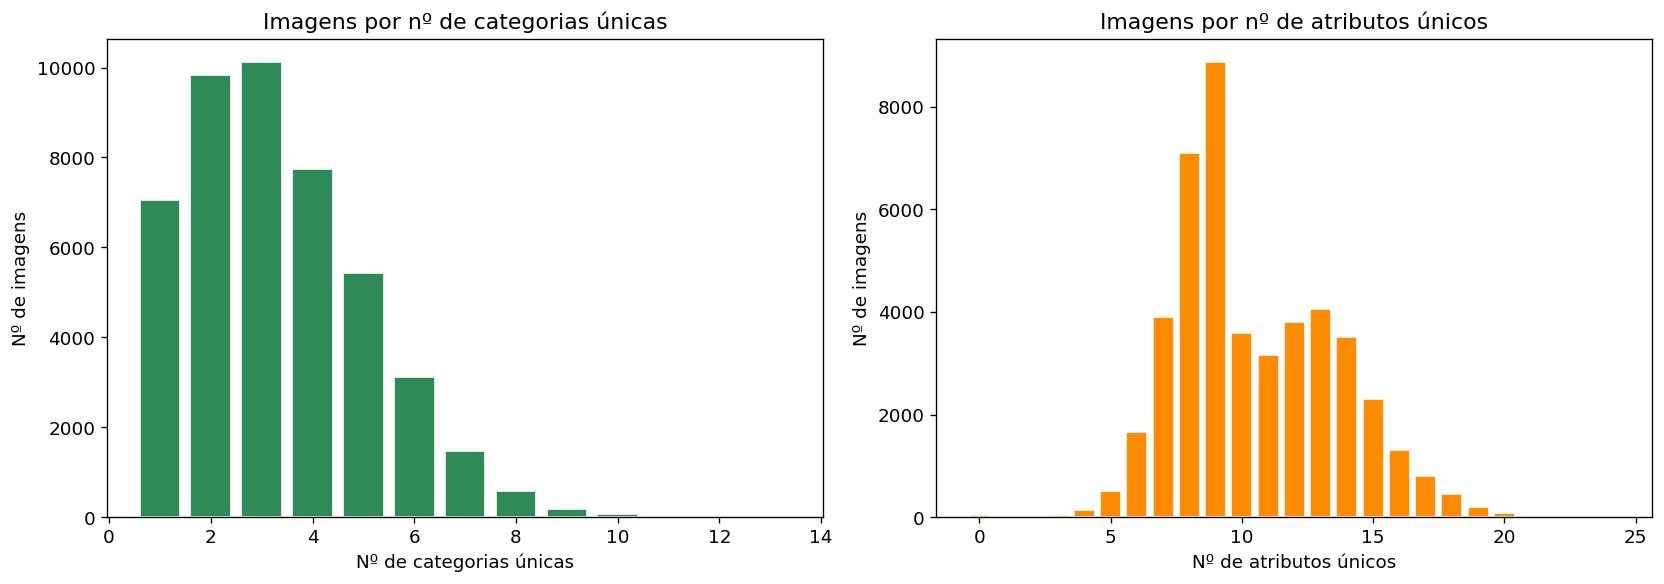

In [24]:
# Distribuição de frequência: quantas imagens têm X categorias?
cat_freq  = per_image['n_categories'].value_counts().sort_index()
attr_freq = per_image['n_attributes'].value_counts().sort_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(cat_freq.index, cat_freq.values, color='seagreen', edgecolor='white')
ax1.set_title('Imagens por nº de categorias únicas')
ax1.set_xlabel('Nº de categorias únicas')
ax1.set_ylabel('Nº de imagens')

ax2.bar(attr_freq.index, attr_freq.values, color='darkorange', edgecolor='white')
ax2.set_title('Imagens por nº de atributos únicos')
ax2.set_xlabel('Nº de atributos únicos')
ax2.set_ylabel('Nº de imagens')

plt.tight_layout()
plt.show()

## Exemplos: 10 imagens com 5 categorias selecionadas

Imagens com exatamente 5 categorias no dataset limpo: 5423


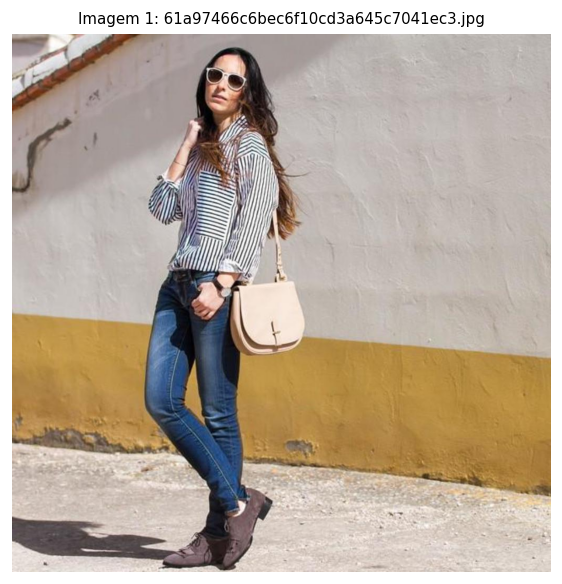

  Categorias (5): shoe, pants, shirt, blouse, watch, bag, wallet

  [shoe]
    (sem atributos)
  [pants]
    straight, jeans, fly (opening), no non-textile material, washed, low waist, maxi (length), plain (pattern)
  [shirt, blouse]
    single breasted, no non-textile material, regular (fit), stripe, normal waist, above-the-hip (length), symmetrical, no special manufacturing technique
  [watch]
    (sem atributos)
  [bag, wallet]
    (sem atributos)
────────────────────────────────────────────────────────────


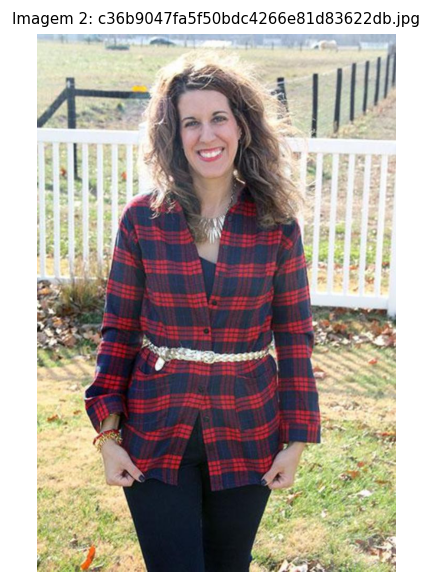

  Categorias (5): top, t-shirt, sweatshirt, belt, buckle, pants, shirt, blouse

  [top, t-shirt, sweatshirt]
    above-the-hip (length), no special manufacturing technique, plain (pattern), no non-textile material, regular (fit), tank (top), symmetrical
  [belt]
    (sem atributos)
  [buckle]
    (sem atributos)
  [pants]
    no special manufacturing technique, plain (pattern), leggings, no non-textile material, regular (fit), maxi (length), symmetrical, fly (opening)
  [shirt, blouse]
    no special manufacturing technique, micro (length), normal waist, no non-textile material, regular (fit), check, single breasted, symmetrical
────────────────────────────────────────────────────────────


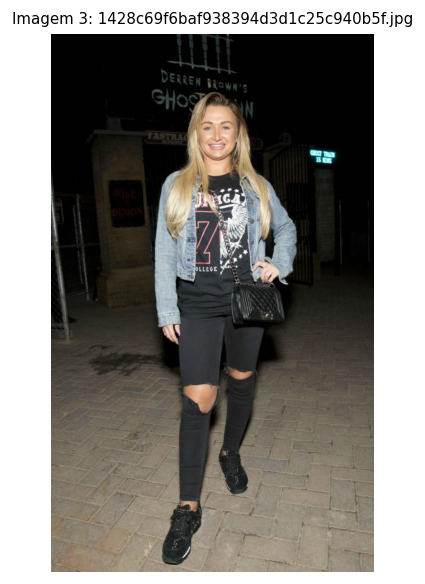

  Categorias (5): bag, wallet, top, t-shirt, sweatshirt, jacket, pants, shoe

  [bag, wallet]
    (sem atributos)
  [top, t-shirt, sweatshirt]
    classic (t-shirt), letters, numbers, no non-textile material, regular (fit), printed, no waistline, hip (length), symmetrical, plain (pattern)
  [jacket]
    single breasted, washed, above-the-hip (length), trucker (jacket), metal, plain (pattern)
  [pants]
    jeans, no non-textile material, distressed, maxi (length), plain (pattern)
  [shoe]
    (sem atributos)
────────────────────────────────────────────────────────────


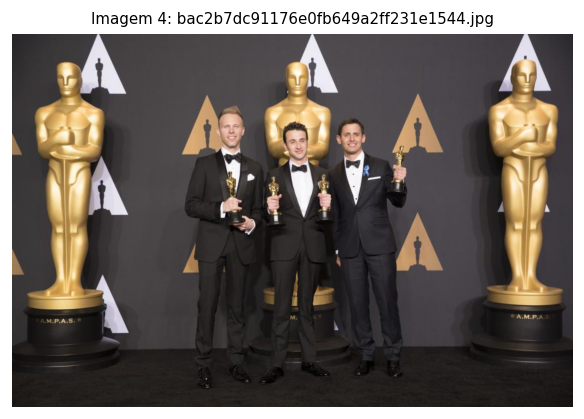

  Categorias (5): shirt, blouse, jacket, pants, shoe, tie

  [shirt, blouse]
    above-the-hip (length), plain (pattern), no special manufacturing technique, normal waist, no non-textile material, regular (fit), single breasted, symmetrical
  [jacket]
    micro (length), plain (pattern), normal waist, no non-textile material, regular (fit), single breasted, lining, symmetrical, tuxedo (jacket)
  [pants]
    no special manufacturing technique, plain (pattern), normal waist, no non-textile material, regular (fit), maxi (length), symmetrical, fly (opening), straight
  [shoe]
    (sem atributos)
  [tie]
    (sem atributos)
────────────────────────────────────────────────────────────


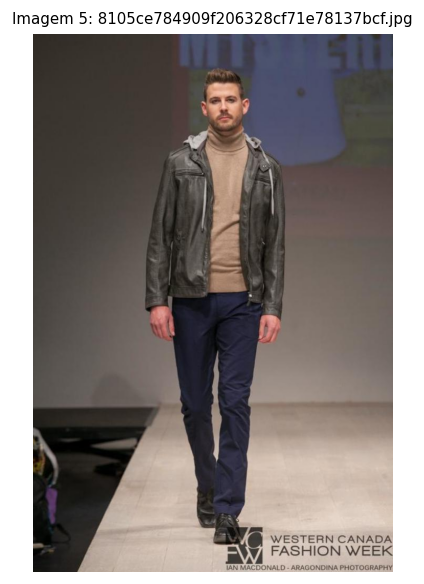

  Categorias (5): shoe, pants, jacket, zipper, top, t-shirt, sweatshirt

  [shoe]
    (sem atributos)
  [pants]
    straight, fly (opening), no non-textile material, maxi (length), no special manufacturing technique, plain (pattern)
  [jacket]
    zip-up, symmetrical, biker (jacket), hip (length), lining, plain (pattern)
  [zipper]
    welt (pocket)
  [top, t-shirt, sweatshirt]
    no non-textile material, tight (fit), symmetrical, hip (length), no special manufacturing technique
────────────────────────────────────────────────────────────


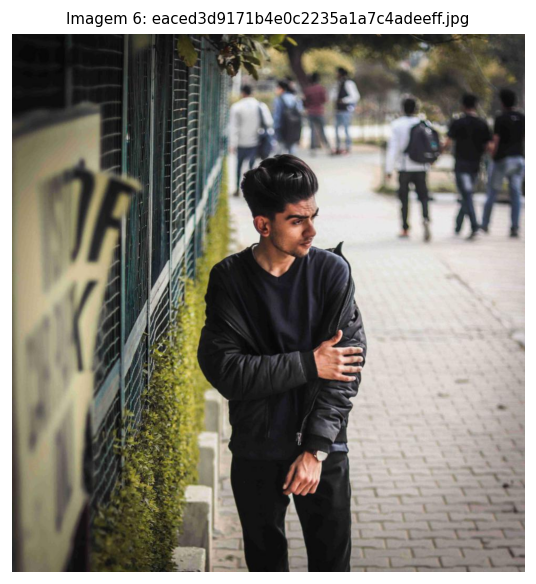

  Categorias (5): top, t-shirt, sweatshirt, zipper, jacket, watch, pants

  [top, t-shirt, sweatshirt]
    above-the-hip (length), no special manufacturing technique, plain (pattern), no non-textile material, regular (fit), classic (t-shirt), symmetrical, no waistline
  [zipper]
    (sem atributos)
  [jacket]
    above-the-hip (length), plain (pattern), normal waist, regular (fit), puffer (jacket), lining, symmetrical, zip-up
  [watch]
    (sem atributos)
  [pants]
    no special manufacturing technique, plain (pattern), jeans, no non-textile material, regular (fit), low waist, symmetrical, fly (opening)
────────────────────────────────────────────────────────────


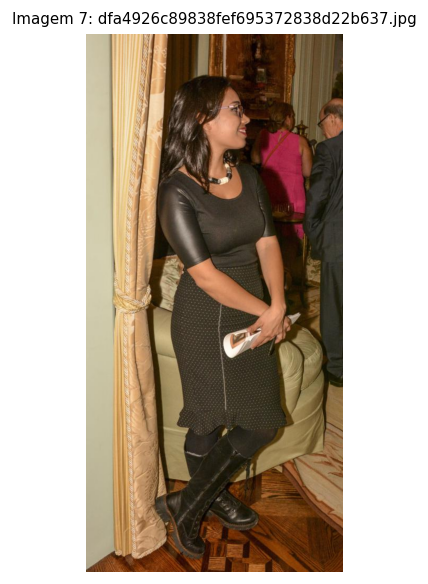

  Categorias (5): top, t-shirt, sweatshirt, tights, stockings, shoe, skirt, glasses

  [top, t-shirt, sweatshirt]
    above-the-hip (length), no special manufacturing technique, plain (pattern), normal waist, no non-textile material, tight (fit), classic (t-shirt), symmetrical
  [tights, stockings]
    (sem atributos)
  [shoe]
    (sem atributos)
  [skirt]
    no special manufacturing technique, dot, no non-textile material, trumpet, knee (length), symmetrical, zip-up, high waist
  [glasses]
    (sem atributos)
────────────────────────────────────────────────────────────


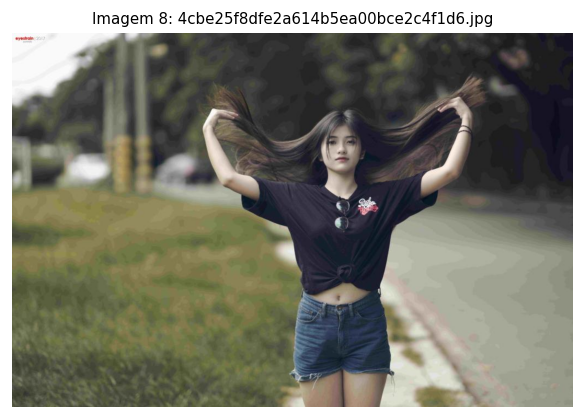

  Categorias (5): glasses, shorts, rivet, top, t-shirt, sweatshirt, zipper

  [glasses]
    (sem atributos)
  [shorts]
    plain (pattern), no non-textile material, regular (fit), washed, short (shorts), low waist, frayed, mini (length), symmetrical, fly (opening)
  [rivet]
    (sem atributos)
  [top, t-shirt, sweatshirt]
    above-the-hip (length), plain (pattern), normal waist, no non-textile material, regular (fit), classic (t-shirt), rivet(a), symmetrical
  [zipper]
    (sem atributos)
────────────────────────────────────────────────────────────


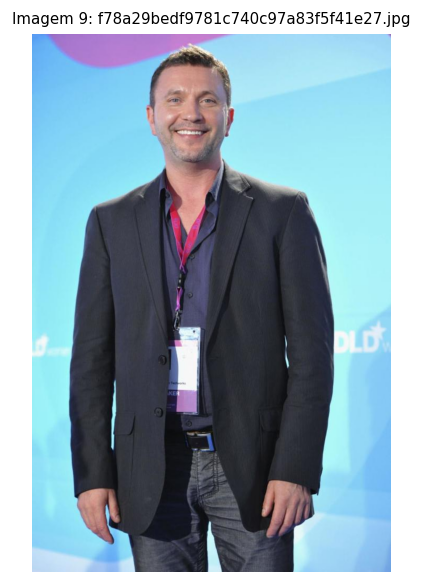

  Categorias (5): coat, pants, belt, buckle, shirt, blouse

  [coat]
    single breasted, no non-textile material, symmetrical, mini (length), lining, plain (pattern)
  [pants]
    jeans, no non-textile material, regular (fit), washed, normal waist, plain (pattern)
  [belt]
    (sem atributos)
  [buckle]
    (sem atributos)
  [shirt, blouse]
    single breasted, regular (fit), above-the-hip (length), symmetrical, no special manufacturing technique, plain (pattern)
────────────────────────────────────────────────────────────


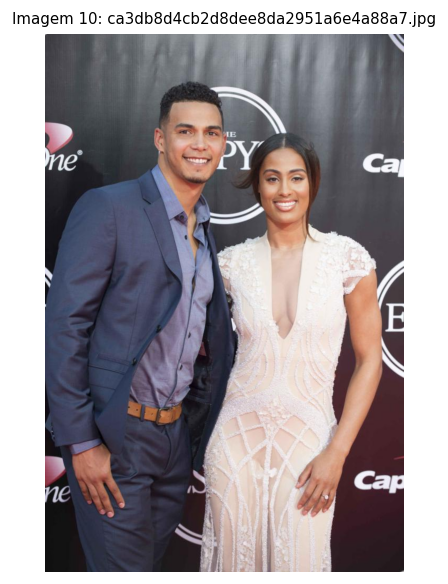

  Categorias (5): pants, buckle, shirt, blouse, belt, jacket

  [pants]
    fly (opening), no non-textile material, regular (fit), low waist, no special manufacturing technique, plain (pattern)
  [buckle]
    (sem atributos)
  [shirt, blouse]
    single breasted, no non-textile material, regular (fit), above-the-hip (length), no special manufacturing technique, plain (pattern)
  [belt]
    (sem atributos)
  [jacket]
    single breasted, no non-textile material, blazer, symmetrical, hip (length), lining, plain (pattern)
────────────────────────────────────────────────────────────


In [ ]:
import json, os, random
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import display

# ── Carregar dataset limpo (sem categorias removidas) ──────────────────────
with open(r'final_datasets\instances_attributes_val2020_clean_no_selected_categories.json') as f:
    data_clean = json.load(f)

# ── Carregar imagens do dataset original (a chave 'images' foi removida no clean) ──
with open(r'original_dataset\instances_attributes_train2020.json') as f:
    data_orig = json.load(f)

images_by_id = {img['id']: img for img in data_orig['images']}
attrs_by_id  = {a['id']: a['name'] for a in data_clean['attributes']}
cats_by_id   = {c['id']: c['name'] for c in data_clean['categories']}

# ── Agrupar anotações por imagem ─────────────────────────────────────────────
annots_by_image = defaultdict(list)
for ann in data_clean['annotations']:
    annots_by_image[ann['image_id']].append(ann)

# ── Filtrar imagens com EXATAMENTE 5 categorias (quaisquer) ──────────────────
IMG_FOLDER = r'C:\Users\Pedro\Downloads\train2020\train'

valid = []
for img_id, anns in annots_by_image.items():
    cat_ids = {a['category_id'] for a in anns}
    if len(cat_ids) == 5:
        img_info = images_by_id.get(img_id)
        if img_info is None:
            continue
        fname = img_info['file_name']
        if os.path.exists(os.path.join(IMG_FOLDER, fname)):
            valid.append(img_id)

print(f'Imagens com exatamente 5 categorias no dataset limpo: {len(valid)}')

random.seed(42)
random.shuffle(valid)
selected = valid[:10]

# ── Plotar ───────────────────────────────────────────────────────────────────
for idx, img_id in enumerate(selected, 1):
    img_info = images_by_id[img_id]
    anns     = annots_by_image[img_id]

    # --- figura com imagem ---
    fig, ax = plt.subplots(figsize=(5, 5))
    img_arr = mpimg.imread(os.path.join(IMG_FOLDER, img_info['file_name']))
    ax.imshow(img_arr)
    ax.axis('off')
    ax.set_title(f'Imagem {idx}: {img_info["file_name"]}', fontsize=9)
    plt.tight_layout()
    plt.show()

    # --- categorias e atributos ---
    cat_to_attrs = defaultdict(list)
    for ann in anns:
        cat_name = cats_by_id[ann['category_id']]
        attr_names = [attrs_by_id[aid] for aid in ann.get('attribute_ids', [])]
        cat_to_attrs[cat_name].extend(attr_names)

    cats_present = list(cat_to_attrs.keys())
    print(f"  Categorias ({len(cats_present)}):")
    for cat_name in cats_present:
        print(f"    - {cat_name}")
    print()
    for cat, attr_list in cat_to_attrs.items():
        attr_str = ', '.join(attr_list) if attr_list else '(sem atributos)'
        print(f"  [{cat}]")
        print(f"    {attr_str}")
    print("─" * 60)
